开始从 Baostock 下载 sh.600519 数据，这可能需要几分钟...
login success!
logout success!
数据下载完成并已保存。
开始滚动回测拟合...


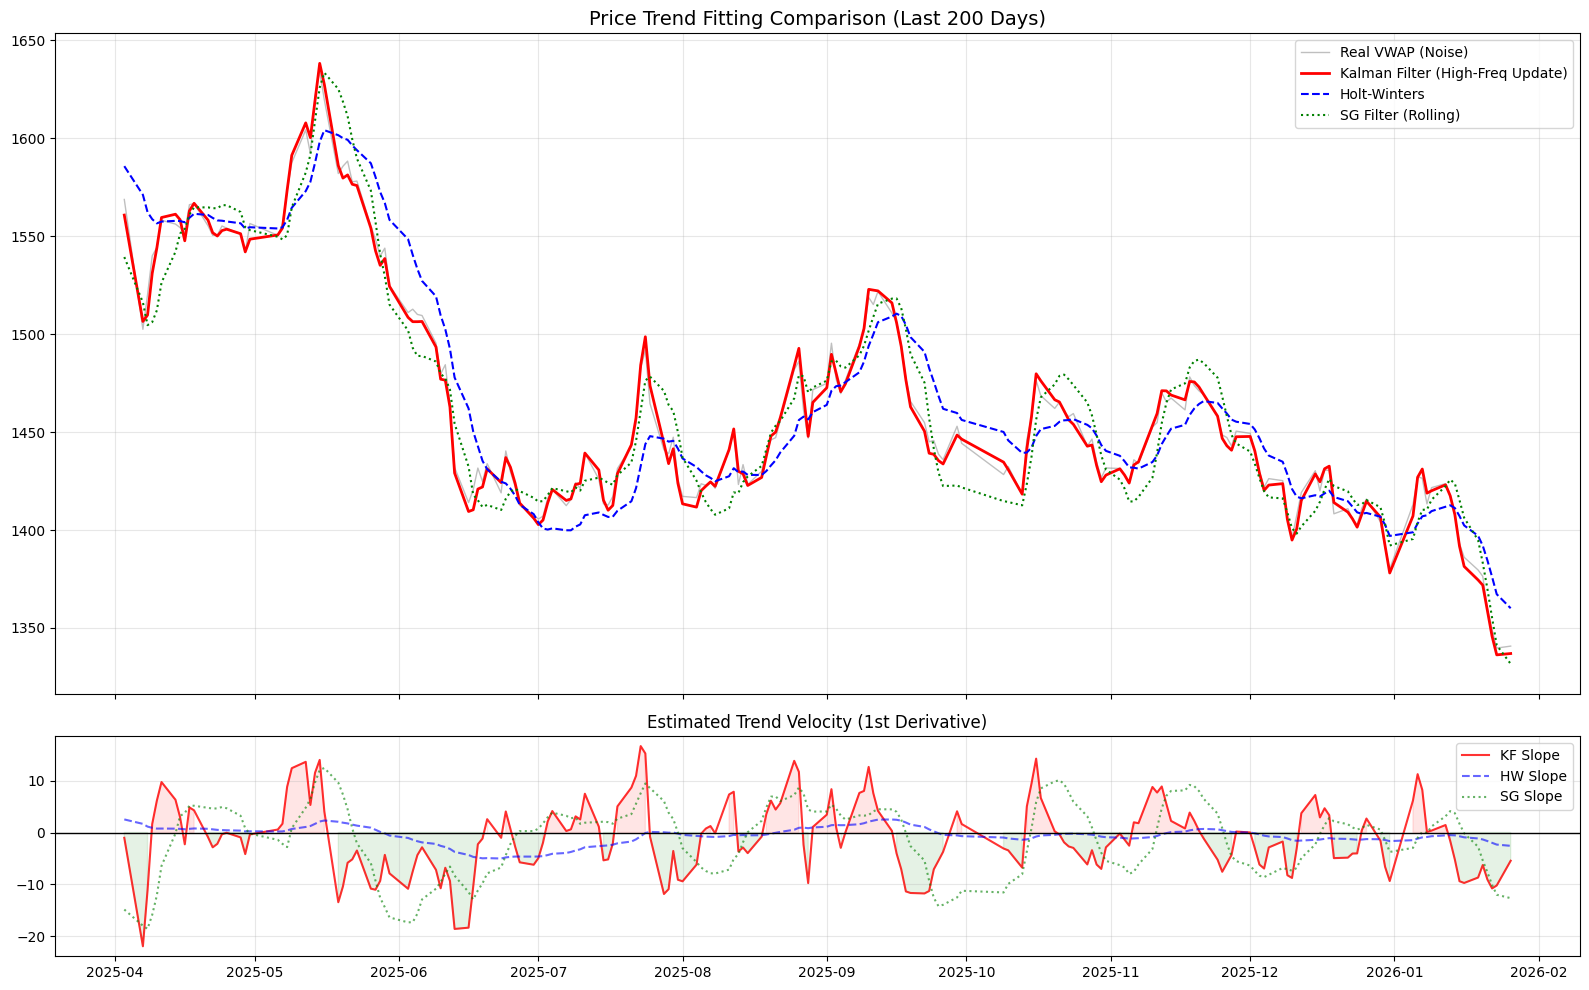

In [ ]:
import baostock as bs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import os

# ==========================================
# 1. 数据引擎模块 (Data Engine)
# ==========================================
class DataEngine:
    def __init__(self, stock_code="sh.600519", start_date="2019-01-01", file_path="moutai_5min.csv"):
        self.stock_code = stock_code
        self.start_date = start_date
        self.file_path = file_path

    def get_data(self):
        # 如果本地有缓存，直接读取
        if os.path.exists(self.file_path):
            print(f"检测到本地数据 {self.file_path}，正在读取...")
            df = pd.read_csv(self.file_path, index_col=0, parse_dates=['time'])
            return df
        
        print(f"开始从 Baostock 下载 {self.stock_code} 数据，这可能需要几分钟...")
        lg = bs.login()
        
        # 获取结束日期为今天
        import datetime
        end_date = datetime.datetime.now().strftime("%Y-%m-%d")
        
        rs = bs.query_history_k_data_plus(
            self.stock_code,
            "date,time,code,open,high,low,close,volume,amount",
            start_date=self.start_date, end_date=end_date,
            frequency="5", adjustflag="3" # 5分钟线，3代表默认不复权(这里建议实战用前复权，但为演示方便暂用默认)
        )
        
        data_list = []
        while (rs.error_code == '0') & rs.next():
            data_list.append(rs.get_row_data())
            
        df = pd.DataFrame(data_list, columns=rs.fields)
        bs.logout()
        
        # 数据清洗
        # 修复方法：先取字符串的前14位，再转换
        df['time'] = df['time'].apply(lambda x: x[:14]) 
        df['time'] = pd.to_datetime(df['time'], format='%Y%m%d%H%M%S')
        
        cols = ['open', 'high', 'low', 'close', 'volume', 'amount']
        for col in cols:
            df[col] = pd.to_numeric(df[col])
            
        # 保存缓存
        df.to_csv(self.file_path)
        print("数据下载完成并已保存。")
        return df

    def prepare_daily_stream(self, df):
        """
        将数据按天分组，生成一个生成器，模拟每天的数据流
        """
        # 提取日期部分
        df['date_str'] = df['time'].dt.date.astype(str)
        grouped = df.groupby('date_str')
        
        for date, group in grouped:
            # 计算当天的 VWAP (成交量加权平均价)
            vwap = (group['close'] * group['volume']).sum() / group['volume'].sum() if group['volume'].sum() > 0 else group['close'].mean()
            yield {
                'date': date,
                'vwap': vwap,
                'intraday_close': group['close'].values # 5分钟收盘价数组
            }

# ==========================================
# 2. 模型核心模块 (Core Models)
# ==========================================

# --- 模型 A: 卡尔曼滤波 (支持日内高频更新) ---
class StreamingKalmanFilter:
    def __init__(self, initial_price):
        # 状态向量 X = [价格, 速度(趋势)]^T
        self.x = np.array([[initial_price], [0.]])
        
        # 状态转移矩阵 F (假设匀速模型)
        # dt 设为 1/48 (假设一天48个bar，时间单位归一化为天)
        dt = 1.0 / 48 
        self.F = np.array([[1, dt],
                           [0, 1]])
        
        # 观测矩阵 H (只能观测到价格)
        self.H = np.array([[1, 0]])
        
        # 协方差矩阵 P (初始不确定性)
        self.P = np.eye(2) * 100
        
        # 过程噪声 Q (相信物理模型的程度，越小越平滑)
        self.Q = np.array([[0.01, 0],
                           [0, 0.01]]) 
        
        # 观测噪声 R (相信数据的程度，越大越不信单根K线的波动)
        self.R = np.array([[50]]) # 针对茅台这种千元股，噪音设大一点
        
    def update_intraday(self, measurements):
        """
        接收一天的所有5分钟收盘价，循环更新状态
        """
        for z in measurements:
            # 1. 预测
            x_pred = self.F @ self.x
            P_pred = self.F @ self.P @ self.F.T + self.Q
            
            # 2. 更新
            # 计算卡尔曼增益
            y = z - self.H @ x_pred # 残差
            S = self.H @ P_pred @ self.H.T + self.R
            K = P_pred @ self.H.T @ np.linalg.inv(S)
            
            self.x = x_pred + K @ y
            self.P = (np.eye(2) - K @ self.H) @ P_pred
            
        # 返回当天的最终估计状态 (价格, 速度)
        return self.x[0, 0], self.x[1, 0]

# --- 模型 B: Holt-Winters (双指数平滑) ---
class OnlineHoltWinters:
    def __init__(self, initial_price, alpha=0.3, beta=0.1):
        self.level = initial_price
        self.trend = 0.0
        self.alpha = alpha # 水平平滑因子
        self.beta = beta   # 趋势平滑因子
        
    def update(self, new_price):
        last_level = self.level
        last_trend = self.trend
        
        # 更新水平 Level
        self.level = self.alpha * new_price + (1 - self.alpha) * (last_level + last_trend)
        # 更新趋势 Trend (即一阶导数)
        self.trend = self.beta * (self.level - last_level) + (1 - self.beta) * last_trend
        
        return self.level, self.trend

# --- 模型 C: 滚动 SG Filter (因果模式) ---
class RollingSGFilter:
    def __init__(self, window_length=15, polyorder=2):
        self.window = window_length
        self.polyorder = polyorder
        self.history = [] # 存储每日 VWAP
        
    def update(self, new_price):
        self.history.append(new_price)
        
        if len(self.history) < self.window:
            # 数据不够时，暂时返回原始值和0趋势
            return new_price, 0.0
        
        # 取最近的一个窗口
        current_window = self.history[-self.window:]
        
        # 拟合 SG
        # deriv=0 拟合价格, deriv=1 拟合一阶导数
        # 关键：只取最后一个点 [-1]，避免未来函数
        fitted_price = savgol_filter(current_window, self.window, self.polyorder, deriv=0)[-1]
        fitted_slope = savgol_filter(current_window, self.window, self.polyorder, deriv=1)[-1]
        
        return fitted_price, fitted_slope

# ==========================================
# 3. 主程序与可视化 (Main & Viz)
# ==========================================
def main():
    # 1. 准备数据
    engine = DataEngine()
    df_raw = engine.get_data()
    
    # 预热数据：取前一天的收盘价初始化模型
    first_price = df_raw['close'].iloc[0]
    
    # 初始化三个模型
    kf = StreamingKalmanFilter(initial_price=first_price)
    hw = OnlineHoltWinters(initial_price=first_price, alpha=0.2, beta=0.05) # 参数可调
    sg = RollingSGFilter(window_length=21, polyorder=2) # 约一个月交易日窗口，单边SG
    
    results = {
        'dates': [],
        'real_vwap': [],
        'kf_price': [], 'kf_slope': [],
        'hw_price': [], 'hw_slope': [],
        'sg_price': [], 'sg_slope': []
    }
    
    print("开始滚动回测拟合...")
    stream = engine.prepare_daily_stream(df_raw)
    
    # 模拟每日推进
    for day_data in stream:
        date = day_data['date']
        vwap = day_data['vwap']
        intraday_prices = day_data['intraday_close']
        
        # Update Kalman (使用5分钟高频数据)
        k_p, k_s = kf.update_intraday(intraday_prices)
        
        # Update HW (使用当日 VWAP)
        h_p, h_s = hw.update(vwap)
        
        # Update SG (使用当日 VWAP)
        s_p, s_s = sg.update(vwap)
        
        # 记录结果
        results['dates'].append(date)
        results['real_vwap'].append(vwap)
        results['kf_price'].append(k_p)
        results['kf_slope'].append(k_s)
        results['hw_price'].append(h_p)
        results['hw_slope'].append(h_s)
        results['sg_price'].append(s_p)
        results['sg_slope'].append(s_s)

    # 转换为 DataFrame 方便绘图
    res_df = pd.DataFrame(results)
    res_df['dates'] = pd.to_datetime(res_df['dates'])
    res_df.set_index('dates', inplace=True)
    
    # 截取最近 200 天的数据进行展示（全数据量太大，图表看不清）
    plot_df = res_df.iloc[-200:] 
    
    # 绘图
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
    
    # 上图：价格拟合对比
    ax1.set_title("Price Trend Fitting Comparison (Last 200 Days)", fontsize=14)
    ax1.plot(plot_df.index, plot_df['real_vwap'], color='gray', alpha=0.5, label='Real VWAP (Noise)', linewidth=1)
    ax1.plot(plot_df.index, plot_df['kf_price'], color='red', label='Kalman Filter (High-Freq Update)', linewidth=2)
    ax1.plot(plot_df.index, plot_df['hw_price'], color='blue', linestyle='--', label='Holt-Winters', linewidth=1.5)
    ax1.plot(plot_df.index, plot_df['sg_price'], color='green', linestyle=':', label='SG Filter (Rolling)', linewidth=1.5)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 下图：一阶导数（趋势强度）对比
    ax2.set_title("Estimated Trend Velocity (1st Derivative)", fontsize=12)
    ax2.plot(plot_df.index, plot_df['kf_slope'], color='red', alpha=0.8, label='KF Slope')
    ax2.plot(plot_df.index, plot_df['hw_slope'], color='blue', alpha=0.6, linestyle='--', label='HW Slope')
    ax2.plot(plot_df.index, plot_df['sg_slope'], color='green', alpha=0.6, linestyle=':', label='SG Slope')
    
    # 添加零轴线
    ax2.axhline(0, color='black', linewidth=1)
    
    # 填充颜色表示涨跌信号
    ax2.fill_between(plot_df.index, 0, plot_df['kf_slope'], where=(plot_df['kf_slope']>=0), color='red', alpha=0.1)
    ax2.fill_between(plot_df.index, 0, plot_df['kf_slope'], where=(plot_df['kf_slope']<0), color='green', alpha=0.1)
    
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()